# Phase Encoding and Decoherence Shrinkage Example
### Custom sequence $y = [2, 1, 9, 0, 3, -10, 2, 4]$ in Qiskit 2.x

This notebook illustrates phase (expectation-value) encoding for a short real sequence.
Each classical coefficient $y_i$ is first rescaled to $[-1, 1]$ and then encoded so that
$$\langle X \rangle_{\psi_i} = x_i,$$
where $x_i$ is the rescaled value. We then apply a phase-damping channel with parameter $\gamma$
to each qubit and verify the multiplicative shrinkage rule
$$\langle X \rangle_{\text{after}, i} \approx \sqrt{1-\gamma}\, x_i.$$
This reproduces the type of shrinkage discussed in the controlled-decoherence framework.

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## 2. Custom sequence and rescaling
We start from $$y = (2, 1, 9, 0, 3, -10, 2, 4),$$ and rescale it linearly to $[-1, 1]$ for phase encoding.

In [3]:
y = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)
y_min, y_max = y.min(), y.max()
x_scaled = 2 * (y - y_min) / (y_max - y_min) - 1.0
print('Original y:          ', y)
print('Rescaled x in [-1,1]:', np.round(x_scaled, 3))

Original y:           [  2.   1.   9.   0.   3. -10.   2.   4.]
Rescaled x in [-1,1]: [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]


## 3. Phase encoding
For each rescaled value $x_i \in [-1, 1]$, we prepare a single-qubit state $|\psi_i\rangle$ such that $$\langle X \rangle_{\psi_i} = x_i.$$
We do this by starting from $|+\rangle$, applying $R_z(\phi_i)$ with $\phi_i = \arccos(x_i)$, and then checking $\langle X \rangle$.

In [4]:
X = Operator([[0, 1], [1, 0]])

def encode_phase_state(x_i: float) -> Statevector:
    phi_i = float(np.arccos(np.clip(x_i, -1.0, 1.0)))
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.rz(phi_i, 0)
    return Statevector.from_instruction(qc)

def expectation_X(state) -> float:
    rho = DensityMatrix(state)
    return float(np.real(rho.expectation_value(X)))

encoded_states = [encode_phase_state(v) for v in x_scaled]
encoded_expectations = [expectation_X(s) for s in encoded_states]
print('Target x_i:         ', np.round(x_scaled, 3))
print('Encoded <X>:        ', np.round(encoded_expectations, 3))

Target x_i:          [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]
Encoded <X>:         [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]


## 4. Phase damping channel and shrinkage (manual Kraus evaluation)
We now apply a phase-damping channel with parameter $\gamma$ using explicit Kraus operators, and compare the resulting $\langle X \rangle$ with the theoretical factor $\sqrt{1-\gamma}\, x_i$.

In [5]:
def phase_damping_kraus_matrices(gamma: float):
    K0 = np.array([[1.0, 0.0], [0.0, np.sqrt(1.0 - gamma)]], dtype=complex)
    K1 = np.array([[0.0, 0.0], [0.0, np.sqrt(gamma)]], dtype=complex)
    return K0, K1

def apply_phase_damping_dm(state, gamma: float) -> DensityMatrix:
    """Apply phase damping to a statevector or density matrix and return a DensityMatrix."""
    rho = DensityMatrix(state).data
    K0, K1 = phase_damping_kraus_matrices(gamma)
    rho_out = K0 @ rho @ K0.conj().T + K1 @ rho @ K1.conj().T
    return DensityMatrix(rho_out)

gamma = 0.6
sqrt_factor = float(np.sqrt(1.0 - gamma))
print('gamma =', gamma, '  sqrt(1-gamma) =', sqrt_factor)

gamma = 0.6   sqrt(1-gamma) = 0.6324555320336759


In [6]:
after_expectations = []
for psi in encoded_states:
    rho_out = apply_phase_damping_dm(psi, gamma)
    after_expectations.append(float(np.real(rho_out.expectation_value(X))))

predicted_after = sqrt_factor * x_scaled
print('Original x_i:            ', np.round(x_scaled, 3))
print('After channel <X>:       ', np.round(after_expectations, 3))
print('Predicted sqrt(1-g)*x_i: ', np.round(predicted_after, 3))

Original x_i:             [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]
After channel <X>:        [ 0.166  0.1    0.632  0.033  0.233 -0.632  0.166  0.3  ]
Predicted sqrt(1-g)*x_i:  [ 0.166  0.1    0.632  0.033  0.233 -0.632  0.166  0.3  ]


## 5. Visualization of shrinkage

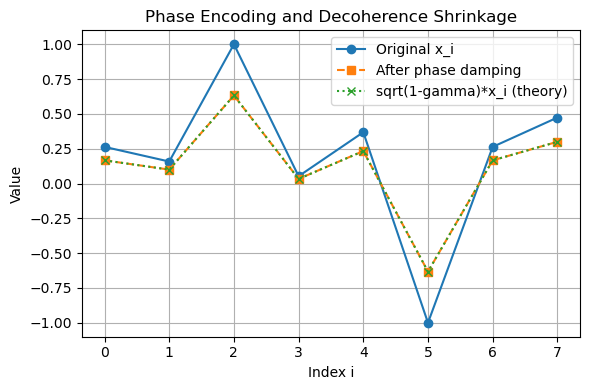

In [7]:
indices = np.arange(len(x_scaled))
plt.figure(figsize=(6, 4))
plt.plot(indices, x_scaled, 'o-', label='Original x_i')
plt.plot(indices, after_expectations, 's--', label='After phase damping')
plt.plot(indices, predicted_after, 'x:', label='sqrt(1-gamma)*x_i (theory)')
plt.xlabel('Index i')
plt.ylabel('Value')
plt.title('Phase Encoding and Decoherence Shrinkage')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("phaseencode.png", dpi=300)
plt.savefig("phaseencode.pdf", dpi=300)


plt.show()

## 6. Summary
We used the sequence $y = (2, 1, 9, 0, 3, -10, 2, 4)$, rescaled it to $[-1, 1]$, and encoded each coefficient
as a single-qubit state with $\langle X \rangle = x_i$. Applying a phase-damping channel with parameter $\gamma$
via explicit Kraus matrices produced shrinkage consistent with $\langle X \rangle_{\text{after}, i} \approx \sqrt{1-\gamma}\, x_i$.